In [1]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
data = Path("data")

In [3]:
datafiler = os.listdir(data)
datafiler.sort()
datafiler

['.ipynb_checkpoints',
 'barnetallsfordeling.csv',
 'befolkningsutvikling_2023_2063_1_5.csv',
 'befolkningsutvikling_2063_2113_1_1-2_1.csv',
 'befolkningsutvikling_2063_2113_1_1.csv',
 'befolkningsutvikling_2063_2113_1_5.csv',
 'popfordeling_2023-2063_tfr1_5.csv',
 'popfordeling_2023-2123_tfr1_5.csv',
 'popfordeling_2063-2113_tfr1_1.csv',
 'popfordeling_2063-2113_tfr1_5.csv',
 'popfordeling_2063-2113_tfr2_1.csv',
 'populasjon_2063_tfr1_5.csv',
 'populasjon_2113_tfr1_1.csv',
 'populasjon_2113_tfr1_5.csv',
 'populasjon_2113_tfr2_1.csv',
 'populasjon_2123_tfr1_5.csv',
 'startpop_no.csv',
 'startpop_no_test.csv']

In [12]:
befolkning_23_63 = pd.read_csv(data / "befolkningsutvikling_2023_2063_1_5.csv")#.iloc[:,1:]
befolkning_23_63.tail(5)

,år,pop_1.5
36,2059,5460516
37,2060,5434944
38,2061,5407415
39,2062,5378160
40,2063,5347261


In [11]:
befolkning_63_23_1_5 = pd.read_csv(data / "befolkningsutvikling_2063_2113_1_5.csv")#.iloc[:,1:]
befolkning_63_23_2_1 = pd.read_csv(data / "befolkningsutvikling_2063_2113_2_1.csv")#.iloc[:,1:]
befolkning_63_23_1_1 = pd.read_csv(data / "befolkningsutvikling_2063_2113_1_1.csv")#.iloc[:,1:]

befolkning_63_23_1_5.head(5)

,år,pop_1.5
0,2063,5347261
1,2064,5315010
2,2065,5282076
3,2066,5248359
4,2067,5214602


In [14]:
befolkning_1_5 = pd.concat([befolkning_23_63, befolkning_63_23_1_5]).reset_index(drop=True)
befolkning_1_5

,år,pop_1.5
0,2023,5488984
1,2024,5499094
2,2025,5508432
3,2026,5517115
4,2027,5525334
...,...,...
87,2109,3561434
88,2110,3525430
89,2111,3490224
90,2112,3455969


In [17]:
befolkning = befolkning_1_5.merge(befolkning_63_23_2_1, on ="år", how="left").merge(befolkning_63_23_1_1, on ="år", how="left")

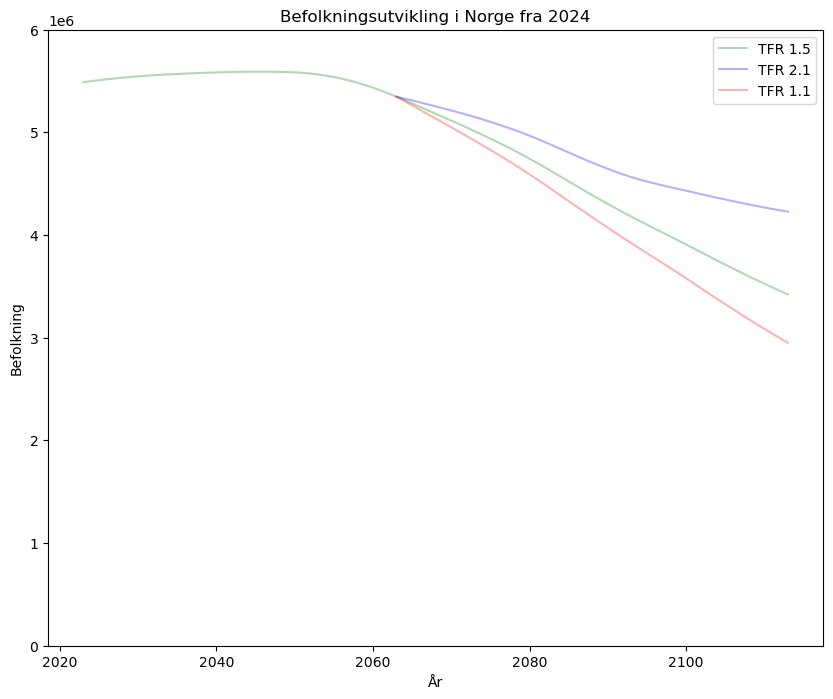

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(befolkning.år, befolkning["pop_1.5"], color='green', alpha = 0.3, label='TFR 1.5')
ax.plot(befolkning.år, befolkning["pop_2.1"], color='blue', alpha = 0.3, label='TFR 2.1')
ax.plot(befolkning.år, befolkning["pop_1.1"], color='red', alpha = 0.3, label='TFR 1.1')

ax.set_ylim(0,6e6)
ax.set_ylabel('Befolkning')
ax.set_xlabel('År')
ax.set_title('Befolkningsutvikling i Norge fra 2024')
ax.legend()

# ax.line()

In [30]:
populasjon_2113_1_5 = pd.read_csv(data / 'popfordeling_2063-2113_tfr1_5.csv')
populasjon_2113_1_1 = pd.read_csv(data / 'popfordeling_2063-2113_tfr1_1.csv')
populasjon_2113_2_1 = pd.read_csv(data / 'popfordeling_2063-2113_tfr2_1.csv')




In [29]:
populasjon_2113_1_1

,sex,alder,pop_2023,pop_2064,pop_2065,pop_2066,pop_2067,pop_2068,pop_2069,pop_2070,...,pop_2104,pop_2105,pop_2106,pop_2107,pop_2108,pop_2109,pop_2110,pop_2111,pop_2112,pop_2113
0,K,0,18502.0,13433.0,13382.0,13269.0,13181.0,13245.0,13138.0,12879.0,...,7020.0,6824.0,6887.0,6776.0,6534.0,6532.0,6577.0,6439.0,6366.0,6298.0
1,K,1,18768.0,18502.0,13433.0,13382.0,13269.0,13181.0,13245.0,13138.0,...,7083.0,7019.0,6824.0,6887.0,6776.0,6534.0,6532.0,6576.0,6439.0,6366.0
2,K,2,18734.0,18766.0,18502.0,13432.0,13382.0,13269.0,13180.0,13245.0,...,7125.0,7083.0,7019.0,6824.0,6887.0,6776.0,6534.0,6532.0,6576.0,6439.0
3,K,3,19065.0,18733.0,18766.0,18501.0,13431.0,13382.0,13269.0,13180.0,...,7324.0,7125.0,7083.0,7019.0,6824.0,6887.0,6775.0,6534.0,6532.0,6576.0
4,K,4,19182.0,19065.0,18732.0,18766.0,18501.0,13431.0,13382.0,13269.0,...,7588.0,7324.0,7125.0,7083.0,7019.0,6824.0,6886.0,6775.0,6534.0,6532.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,M,105,4.0,3.0,5.0,4.0,8.0,7.0,4.0,2.0,...,12.0,8.0,11.0,12.0,9.0,18.0,11.0,7.0,11.0,12.0
216,M,106,NaN,1.0,1.0,3.0,1.0,3.0,2.0,2.0,...,2.0,4.0,2.0,5.0,8.0,4.0,5.0,3.0,NaN,4.0
217,M,107,NaN,NaN,NaN,NaN,1.0,1.0,1.0,2.0,...,1.0,NaN,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
218,M,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


In [44]:
pop = pd.read_csv(data / 'popfordeling_2023-2123_tfr1_5.csv')
pop

,sex,alder,pop_2023,pop_2024,pop_2025,pop_2026,pop_2027,pop_2028,pop_2029,pop_2030,...,pop_2114,pop_2115,pop_2116,pop_2117,pop_2118,pop_2119,pop_2120,pop_2121,pop_2122,pop_2123
0,K,0,25310.0,27008.0,26824.0,26391.0,26238.0,25905.0,25543.0,25220.0,...,11563.0,11343.0,11247.0,11175.0,10973.0,10856.0,10887.0,10706.0,10521.0,10389.0
1,K,1,28037.0,25308.0,27004.0,26822.0,26390.0,26236.0,25900.0,25536.0,...,11689.0,11563.0,11343.0,11247.0,11175.0,10971.0,10856.0,10886.0,10706.0,10520.0
2,K,2,26820.0,28032.0,25303.0,26996.0,26817.0,26390.0,26235.0,25896.0,...,11633.0,11689.0,11562.0,11343.0,11246.0,11175.0,10971.0,10856.0,10886.0,10706.0
3,K,3,27466.0,26814.0,28030.0,25300.0,26994.0,26815.0,26385.0,26230.0,...,11806.0,11633.0,11689.0,11562.0,11342.0,11245.0,11175.0,10970.0,10856.0,10886.0
4,K,4,27692.0,27464.0,26811.0,28021.0,25297.0,26991.0,26814.0,26382.0,...,11960.0,11806.0,11632.0,11689.0,11562.0,11342.0,11245.0,11175.0,10969.0,10856.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,M,105,28.0,NaN,4.0,2.0,NaN,NaN,1.0,NaN,...,12.0,8.0,11.0,12.0,13.0,10.0,12.0,12.0,14.0,12.0
216,M,106,NaN,8.0,NaN,2.0,1.0,NaN,NaN,NaN,...,6.0,5.0,4.0,3.0,7.0,4.0,3.0,4.0,7.0,7.0
217,M,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,2.0,2.0
218,M,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
pop = pop[["sex","alder", "pop_2023", "pop_2113"]]
pop

,sex,alder,pop_2023,pop_2113
0,K,0,25310.0,11689.0
1,K,1,28037.0,11634.0
2,K,2,26820.0,11806.0
3,K,3,27466.0,11960.0
4,K,4,27692.0,12065.0
...,...,...,...,...
215,M,105,28.0,13.0
216,M,106,NaN,6.0
217,M,107,NaN,3.0
218,M,108,NaN,NaN


In [46]:
pop = pop.groupby("alder")[["pop_2023", "pop_2113"]].sum()

In [47]:
pop

,pop_2023,pop_2113
alder,,
0,51991.0,23222.0
1,57415.0,23512.0
2,54778.0,23791.0
3,56455.0,23941.0
4,57146.0,24184.0
...,...,...
105,104.0,25.0
106,0.0,10.0
107,0.0,4.0


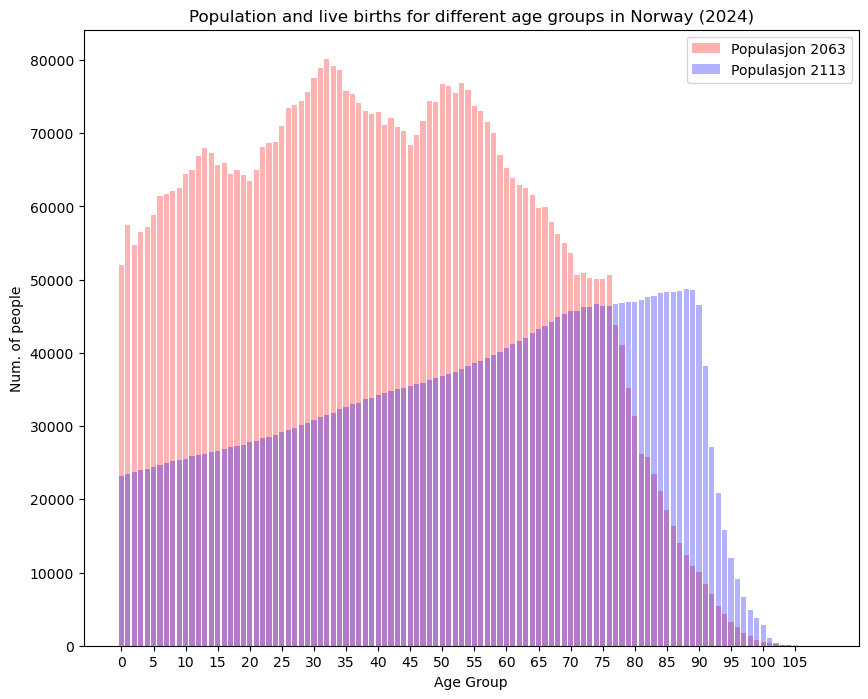

In [48]:
df = pop

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))


ax.bar(pop.index, pop['pop_2023'], color='red', alpha = 0.3, label='Populasjon 2063')
ax.bar(pop.index, pop['pop_2113'], color='blue', alpha = 0.3, label='Populasjon 2113')
# ax.barh(kvinner['alder'], -kvinner['2024'], color='orangered', label='Women')

ax.set_ylabel('Num. of people')
ax.set_xlabel('Age Group')
ax.set_title('Population and live births for different age groups in Norway (2024)')
ax.legend()


# Customizing the x-axis to show positive values for both sides
ax.set_xticks(range(0,len(df.index),5))
ax.set_xticklabels(range(0,len(df.index),5))


# plt.savefig("Figures/ASFR_2024.png", format="png", dpi=300)

plt.show()

In [13]:
pop["diff"] = pop["pop_2050"] - pop["pop_2023"]
pop

,pop_2023,pop_2050,diff
alder,,,
0,520.0,1383.0,863.0
1,574.0,1373.0,799.0
2,548.0,1432.0,884.0
3,565.0,1423.0,858.0
4,572.0,1433.0,861.0
...,...,...,...
105,1.0,0.0,-1.0
106,0.0,0.0,0.0
107,0.0,0.0,0.0


In [47]:
pop["diff"].sum()

KeyError: 'diff'

In [15]:
pop = pop.reset_index()
pop

,alder,pop_2023,pop_2050,diff
0,0,520.0,1383.0,863.0
1,1,574.0,1373.0,799.0
2,2,548.0,1432.0,884.0
3,3,565.0,1423.0,858.0
4,4,572.0,1433.0,861.0
...,...,...,...,...
105,105,1.0,0.0,-1.0
106,106,0.0,0.0,0.0
107,107,0.0,0.0,0.0
108,108,0.0,0.0,0.0


In [15]:
bins = list(range(0, 114, 5))

# Lag bins og gi dem lesbare etiketter
pop["aldersgruppe"] = pd.cut(pop["alder"], bins=bins, right=False, include_lowest=True,
                    labels=[f"{i}-{i+4}" for i in range(0, 109, 5)])



In [16]:
age_groups

NameError: name 'age_groups' is not defined

In [17]:
pop_binned = pop.groupby("aldersgruppe")[["pop_2023","pop_2050"]].sum().reset_index()

In [18]:
pop_binned

,aldersgruppe,pop_2023,pop_2050
0,0-4,277785.0,239428.0
1,5-9,306608.0,253695.0
2,10-14,331674.0,261991.0
3,15-19,325360.0,270828.0
4,20-24,333966.0,285142.0
5,25-29,368198.0,299704.0
6,30-34,394345.0,325551.0
7,35-39,370973.0,351647.0
8,40-44,357260.0,362849.0
9,45-49,358569.0,357522.0


In [19]:
pop_binned["diff"] = pop_binned["pop_2050"] - pop_binned["pop_2023"]
pop_binned

,aldersgruppe,pop_2023,pop_2050,diff
0,0-4,277785.0,239428.0,-38357.0
1,5-9,306608.0,253695.0,-52913.0
2,10-14,331674.0,261991.0,-69683.0
3,15-19,325360.0,270828.0,-54532.0
4,20-24,333966.0,285142.0,-48824.0
5,25-29,368198.0,299704.0,-68494.0
6,30-34,394345.0,325551.0,-68794.0
7,35-39,370973.0,351647.0,-19326.0
8,40-44,357260.0,362849.0,5589.0
9,45-49,358569.0,357522.0,-1047.0


In [20]:
pop_binned.iloc[4:8]["diff"].sum()

-205438.0

In [21]:
pop_binned["diff"].sum()

280307.0

In [22]:
år = 2043

fremskrivning_1 = pd.read_csv(data / f"utvikling_{år}.csv").rename(columns={"0":"2.1"})

fremskrivning_1["år"] = range(år, år+ len(fremskrivning_21))
fremskrivning_1

NameError: name 'fremskrivning_21' is not defined

In [23]:
år = 2063

fremskrivning_2 = pd.read_csv(data / f"utvikling_{år}.csv").rename(columns={"0":"2.1"})

fremskrivning_2["år"] = range(år, år+ len(fremskrivning_2))
fremskrivning_2

,2.1,år
0,5632283,2063
1,5645971,2064
2,5659099,2065
3,5671764,2066
4,5683222,2067
...,...,...
72,4729343,2135
73,4731783,2136
74,4734443,2137
75,4737340,2138


In [24]:
år = 2083

fremskrivning_3 = pd.read_csv(data / f"utvikling_{år}.csv").rename(columns={"0":"2.1"})

fremskrivning_3["år"] = range(år, år+ len(fremskrivning_3))
fremskrivning_3

,2.1,år
0,5096082,2083
1,5096219,2084
2,5095355,2085
3,5092995,2086
4,5088512,2087
5,5082098,2088
6,5073755,2089
7,5063418,2090
8,5050959,2091
9,5037069,2092


In [25]:
befolkning_for_2023 = pd.read_csv("befolkning.csv")#.loc[lambda x: x.år <= 2022]

In [26]:
liste_med_fremskrivninger = [fremskrivning_1, fremskrivning_2, fremskrivning_3]

In [27]:
befolkning_for_2023
df1 = pd.DataFrame(befolkning_for_2023).loc[lambda x: x.år < 2024]

In [28]:
fremskrivning_1.loc[0,"år"]

KeyError: 'år'

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df1['år'], df1['pop'], label='1986-2024', color='blue')
plt.plot(befolkning.år, befolkning["pop_1.5"]) 
# plt.plot(df1['år'], df1['pop'], label='1986-2024', color='blue')

for df in liste_med_fremskrivninger:
    print(df.head(1))
    plt.plot(df.år, df["2.1"], label=f"Fremskrivning fra {df.loc[0,'år']}")

plt.xlabel('År')
plt.ylabel('Befolkning')
plt.scatter(x=2025, y= befolkning.loc[lambda x: x.år == 2025]["pop_1.5"], color="red", s = 20, zorder = 5, label = "Første fremskrivning med TFR = 1.4")
plt.legend()
plt.ylim(0, 6.5e6)
#plt.grid(True)
plt.show()

In [ ]:
bilder = Path("Figures") / "aldersfordeling"

In [ ]:
plt.savefig(bilder / f"aldersutvikling.jpg", format="jpg", dpi=50)

In [ ]:
popfordeling_2043-2140_tfr2_1.csv